# Traffic Death Analysis

In this exercise, we will be analyzing the effect of alcohol taxes on traffic death in the United States.  The data set used in this exercise, `fatalities.csv`, is a state-year panel dataset (meaning it includes data on multiple states, and the data includes several years of data for each state. The data contains 336 observations on 34 variables. The variables used in the exercise are defined as follows:

`state`: factor variable indicating states

`year`: factor variable indicating years

`beertax`: numeric variable, Tax on the case of beer

In these exercises, we'll be looking at how beer taxes (which are believed to reduce alcohol consumption, potentially reducing drunk driving deaths) impact car accident fatality rates. 

More specifically, though, we'll be approaching our estimation of the impact of beer taxes in a few different ways in an effort to give you more of an intuitive sense of what happens when you add fixed effects to a regression. 



## Gradescope Autograding

Please follow [all standard guidance](https://www.practicaldatascience.org/ids720_specific/autograder_guidelines.html) for submitting this assignment to the Gradescope autograder, including storing your solutions in a dictionary called `results` and ensuring your notebook runs from the start to completion without any errors.

For this assignment, please name your file `exercise_panel.ipynb` before uploading.

You can check that you have answers for all questions in your `results` dictionary with this code:

```python
assert set(results.keys()) == {
    "ex1_num_states",
    "ex1_num_years",
    "ex2_avg_fatality_rate",
    "ex4_pooled_beta",
    "ex5_statefe_beta",
    "ex6_demeaned_beta",
    "ex7_panelols_beta",
    "ex7_panelols_se",
    "ex8_twfe_beta",
}
```

### Submission Limits

Please remember that you are **only allowed THREE submissions to the autograder.** Your last submission (if you submit 3 or fewer times), or your third submission (if you submit more than 3 times) will determine your grade Submissions that error out will **not** count against this total.


## Exercise 1

Download and load the data from [this link](https://github.com/nickeubank/MIDS_Data/blob/master/UDS_arrest_data.csv), or by going to [http://www.github.com/nickeubank/MIDS_Data/](http://www.github.com/nickeubank/MIDS_Data/) and downloading the `us_driving_fatalities.csv` dataset. 

How many states does this dataset contain? What's the time frame of this dataset? (From which year to which year). And what constitutes a single observation (i.e. what is the unit of analysis for each row of the data?)

Store the number of states in `"ex1_num_states"` and number of years in `"ex1_num_years"`

In [14]:
import numpy as np
import pandas as pd

pd.set_option("mode.copy_on_write", True)
url = "https://github.com/nickeubank/MIDS_Data/raw/refs/heads/master/us_driving_fatalities.csv"
df = pd.read_csv(url)
results = {}
df

,Unnamed: 0,state,year,spirits,unemp,income,emppop,beertax,baptist,mormon,...,nfatal2124,afatal,pop,pop1517,pop1820,pop2124,milestot,unempus,emppopus,gsp
0,1,al,1982,1.37,14.4,10544.152344,50.692039,1.539379,30.355700,0.32829,...,32,309.437988,3.942002e+06,208999.593750,221553.437500,290000.062500,28516.0,9.7,57.799999,-0.022125
1,2,al,1983,1.36,13.7,10732.797852,52.147030,1.788991,30.333599,0.34341,...,35,341.834015,3.960008e+06,202000.078125,219125.468750,290000.156250,31032.0,9.6,57.900002,0.046558
2,3,al,1984,1.32,11.1,11108.791016,54.168087,1.714286,30.311501,0.35924,...,34,304.872009,3.988992e+06,196999.968750,216724.093750,288000.156250,32961.0,7.5,59.500004,0.062798
3,4,al,1985,1.28,8.9,11332.626953,55.271137,1.652542,30.289499,0.37579,...,45,276.742004,4.021008e+06,194999.734375,214349.031250,284000.312500,35091.0,7.2,60.100002,0.027490
4,5,al,1986,1.23,9.8,11661.506836,56.514496,1.609907,30.267401,0.39311,...,29,360.716003,4.049994e+06,203999.890625,212000.000000,263000.281250,36259.0,7.0,60.700001,0.032143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
331,332,wy,1984,1.91,6.3,13456.043945,66.022095,0.049451,2.630720,8.55593,...,3,62.278999,5.129998e+05,21999.941406,24821.398438,36999.839844,5127.0,7.5,59.500004,-0.016678
332,333,wy,1985,1.88,7.1,13595.338867,65.083801,0.047669,2.720570,8.54494,...,7,52.345001,5.089996e+05,22000.021484,24407.244141,35000.218750,5401.0,7.2,60.100002,-0.012126
333,334,wy,1986,1.70,9.0,13126.934570,63.966484,0.046440,2.813500,8.53397,...,11,57.856998,5.069999e+05,23000.005859,23999.998047,34999.789062,5384.0,7.0,60.700001,-0.109976
334,335,wy,1987,1.59,8.6,12719.000000,62.857143,0.045000,2.909600,8.52302,...,4,35.500000,4.900005e+05,22000.021484,22999.916016,32999.671875,5367.0,6.2,61.500000,-0.123641


In [15]:
ex1_num_states = df["state"].nunique()
ex1_num_years = df["year"].max() - df["year"].min() + 1
print("the data is from", df["year"].max(), "to", df["year"].min())
print("Each observation is a single year for a single state")
results["ex1_num_states"] = ex1_num_states
results["ex1_num_years"] = ex1_num_years

results

the data is from 1988 to 1982
Each observation is a single year for a single state


{'ex1_num_states': 48, 'ex1_num_years': 7}

## Exercise 2

We use the fatality rate per 10,000 as the dependent variable, which you can compute using total fatalities(`fatal`) and population (`pop`). Note that because `pop` is often the name of a method in Python, you may have to navigate around some issues.

Please store the average fatality rate per 10_000 in for the dataset in `"ex2_avg_fatality_rate"`.

In [16]:
df["fat_rate"] = df["fatal"] / df["pop"] * 10_000
results["ex2_avg_fatality_rate"] = df["fat_rate"].mean()
results

{'ex1_num_states': 48,
 'ex1_num_years': 7,
 'ex2_avg_fatality_rate': 2.040443784423569}

## Exercise 3

Draw a scatter plot using `beertax` as the x-axis, and `fat_rate` as the y-axis. Draw a fitted line showing the correlation between these two variables

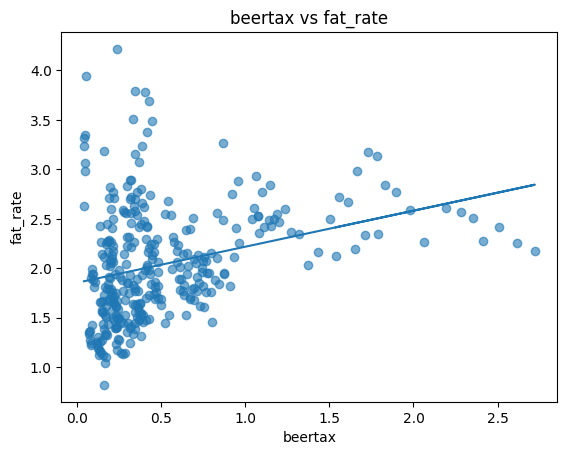

In [17]:
import matplotlib.pyplot as plt

plt.scatter(df["beertax"], df["fat_rate"], alpha=0.6)

# Fit linear regression line
m, b = np.polyfit(df["beertax"], df["fat_rate"], 1)
plt.plot(df["beertax"], m * df["beertax"] + b)

plt.xlabel("beertax")
plt.ylabel("fat_rate")
plt.title("beertax vs fat_rate")

plt.show()

## Exercise 4

Fit a simple OLS regression. This is sometimes called a "pooled" regression because we're "pooling" observations from different years into a single regression with no consideration of the time structure. 

Store the coefficient on beer tax in `"ex4_pooled_beta"`.

What do your results imply about the relationship between Beer Taxes and fatalities?

\begin{align*}
FatalityRate_i = \beta_0 + \beta_1 \times BeerTax_i
\end{align*}

In [18]:
import statsmodels.api as sm

X = df["beertax"]
X = sm.add_constant(X)
y = df["fat_rate"]

model = sm.OLS(y, X).fit()

results["ex4_pooled_beta"] = model.params["beertax"]
results

{'ex1_num_states': 48,
 'ex1_num_years': 7,
 'ex2_avg_fatality_rate': 2.040443784423569,
 'ex4_pooled_beta': 0.36460544036774156}

From the value of beta, which is 0.36, we can see that the fatality rate and bear taxes are positively related. 

## Exercise 5

Now estimate your model again, this time adding state fixed effects (using the `C()` notation and your normal linear model machinery). What does this result imply about the relationship between beer taxes and fatalities?

Store the coefficient under `"ex5_statefe_beta"`



In [19]:
import statsmodels.formula.api as smf

fe_model = smf.ols("fat_rate ~ beertax + C(state)", data=df).fit()

results["ex5_statefe_beta"] = fe_model.params["beertax"]

results

{'ex1_num_states': 48,
 'ex1_num_years': 7,
 'ex2_avg_fatality_rate': 2.040443784423569,
 'ex4_pooled_beta': 0.36460544036774156,
 'ex5_statefe_beta': -0.6558737221504818}

From the value of beta, which is -0.66, we can see that the fatality rate and bear taxes are negatively related when taking fixed effect into account. 

## Exercise 6

Explain whey your results in Exercises 4 (without fixed effects) and Exercise 5 (with state fixed effects) look so different. What does this imply about states with high beer taxes?

In the pooled model, we ignore the hierarchical structure of the data and combine both within-state and between-state variation. As a result, the positive coefficient likely captures cross-state differences, meaning that states with systematically higher beer taxes also tend to have higher baseline fatality rates due to persistent state characteristics. When we introduce state fixed effects, we control for these time-invariant group-level differences. The model then isolates within-state variation over time, and the coefficient turns negative. This implies that after accounting for state-level group effects, increases in beer taxes within a state are associated with reductions in fatality rates.

## Fixed Effects by Demeaning

Rather than just add indicator variables, we'll now use a different strategy for estimating fixed effects called an "entity-demeaning." This method is more computationally efficient, and can also help you understand how fixed effects work. 

Let's begin by assuming we want to estimate the following fixed-effect model:

\begin{align}
FatalityRate_{it} = \alpha + \beta BeerTax_{it} + \Psi Z_i + \epsilon_{it} \tag{1}
\end{align}

Where $FatalityRate_{it}$ is the fatality rate of state $i$ in year $t$, $\beta BeerTax_{it}$ is the beer tax of state $i$ in year $t$. $Z_i$ is a state fixed effect.

Rather than adding indicator variables, however, we'll use entity-demean as follows: 

First, we take the average on both sides of the regression. Here $n$ is the number of periods. 

\begin{align*}
\frac{1}{n} \sum_{i=1}^n FatalityRate_{it} =&  \,\alpha+ \beta_1 \frac{1}{n} \sum_{i=1}^n BeerTax_{it} + \Psi \frac{1}{n} \sum_{i=1}^n Z_i + \frac{1}{n} \sum_{i=1}^n \epsilon_{it} \\
\overline{FatalityRate}_i =& \,\alpha+ \beta_1 \overline{BeerTax}_i + \Psi  Z_i + \overline{\epsilon}_i.  \tag{2}
\end{align*}

Substracting the  from the main equation yields:

\begin{align*}
FatalityRate_{it} - \overline{FatalityRate}_i =& \, \beta_1(BeerTax_{it}-\overline{BeerTax}_i) + \Psi (Z_i - Z_i) + (\epsilon_{it} - \overline{\epsilon}_i)  \\
\overset{\sim}{FatalityRate}_{it} =& \, \beta_1 \overset{\sim}{BeerTax}_{it} + \overset{\sim}{\epsilon}_{it}  \tag{3}
\end{align*}

Where the $\sim$ means values have been demeaned by group. 

By taking the difference between the value of each observation (state-year) and the mean value of the entity (state) over n periods, we analyze how the within-state variation of beer tax affects that of the fatality rate. Moreover, by doing so we no longer need to estimate the fixed effects of $Z_i$, saving computing power if we are working on a dataset with a large number of fixed effects.

## Exercise 6

Implement the above entity-demeaned approach to estimate the fixed-effects model by hand (use basic functions, not full tools like `PanelOLS` or `C()` notation in `python`).

Compare your answer to the answer you got in Ex 5.

In [20]:
y_bar_i = df.groupby("state")["fat_rate"].transform("mean")
x_bar_i = df.groupby("state")["beertax"].transform("mean")

y_tilde = df["fat_rate"] - y_bar_i
x_tilde = df["beertax"] - x_bar_i


results["ex6_demeaned_beta"] = (x_tilde @ y_tilde) / (x_tilde @ x_tilde)
results

{'ex1_num_states': 48,
 'ex1_num_years': 7,
 'ex2_avg_fatality_rate': 2.040443784423569,
 'ex4_pooled_beta': 0.36460544036774156,
 'ex5_statefe_beta': -0.6558737221504818,
 'ex6_demeaned_beta': -0.6558737221504344}

It is the same as the answer in question5.

## Exercise 7 

Fit the model with state fixed-effect using `PanelOLS` / `lfe`. Note that PanelOLS automatically clusters standard errors when you add `EntityEffects` (unlike statsmodel's OLS function).

Compare it to your by-hand output. Store your coefficient in `"ex7_panelols_beta"` and your standard error `"ex7_panelols_se"`.

Interpret the result, including standard errors.

In [21]:
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

# Set multi-index (required for PanelOLS)
df_panel = df.set_index(["state", "year"])
y = df_panel["fat_rate"]
X = sm.add_constant(df_panel[["beertax"]])

res = PanelOLS(y, X, entity_effects=True).fit()

# Fit fixed effects model (entity effects)
model_panel = PanelOLS.from_formula(
    "fat_rate ~ 1 + beertax + EntityEffects", data=df_panel
).fit(cov_type="clustered", cluster_entity=True)

# Store results
# results["ex7_panelols_beta"] = model_panel.params["beertax"]
# results["ex7_panelols_se"] = model_panel.std_errors["beertax"]

results["ex7_panelols_beta"] = float(res.params["beertax"])
results["ex7_panelols_se"] = float(res.std_errors["beertax"])


results

{'ex1_num_states': 48,
 'ex1_num_years': 7,
 'ex2_avg_fatality_rate': 2.040443784423569,
 'ex4_pooled_beta': 0.36460544036774156,
 'ex5_statefe_beta': -0.6558737221504818,
 'ex6_demeaned_beta': -0.6558737221504344,
 'ex7_panelols_beta': -0.6558737221504364,
 'ex7_panelols_se': 0.18784999357613877}

The PanelOLS estimate is −0.656, with a clustered standard error of 0.289. This means that within a state, a one-unit increase in beer tax is associated with about a 0.66 decrease in the fatality rate, on average. Because the standard error is 0.289, the coefficient is a little more than 2 standard errors away from zero (−0.656 / 0.289 ≈ 2.27).

## Exercise 8

Now (using `PanelOLS`) estimate a fixed effects model using the following specification. Add fixed effects for **both** the state and the year, as well as the other covariates you think are important $X_{it}$). 

(Note: you may want to make sure `PanelOLS` adds an intercept to aid in interpretation of controls if you include categorical variables. If you use `PanelOLS.from_formula()`, just put a `1+` in after the `~`, or add a column of 1s to your X matrix if you're working with numpy arrays.)

Explain (a) the type of phenomenon we control for by adding `year` fixed effects, and (b) your choice of covariates. 

Put your beer tax coefficient in `"ex8_twfe_beta"`.

Interpret the result.

\begin{align}
FatalityRate_{it} = \alpha + \beta BeerTax_{it} + X_{it} + State_i + Year_t + \epsilon_{it}
\end{align}

In [22]:
df_panel = df.set_index(["state", "year"])


# TWFE model
model_twfe = PanelOLS.from_formula(
    f"fat_rate ~ 1 + beertax+ EntityEffects + TimeEffects", data=df_panel
).fit(cov_type="clustered", cluster_entity=True)


results["ex8_twfe_beta"] = model_twfe.params["beertax"]

results

{'ex1_num_states': 48,
 'ex1_num_years': 7,
 'ex2_avg_fatality_rate': 2.040443784423569,
 'ex4_pooled_beta': 0.36460544036774156,
 'ex5_statefe_beta': -0.6558737221504818,
 'ex6_demeaned_beta': -0.6558737221504344,
 'ex7_panelols_beta': -0.6558737221504364,
 'ex7_panelols_se': 0.18784999357613877,
 'ex8_twfe_beta': -0.6399799857068735}

Adding year fixed effects controls for nationwide time shocks that affect all states in a given year. Examples include improvements in vehicle safety, federal highway policies, macroeconomic conditions, or cultural changes that influence driving behavior. By including year fixed effects, we remove common time trends that could otherwise bias the estimated relationship between beer taxes and fatality rates.

I included population (pop) as a control because changes in population size may influence traffic density and accident risk over time within states. Controlling for population helps isolate the effect of beer taxes from demographic changes.